In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("monthly_csv.csv")
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [3]:
df.shape

(847, 2)

In [4]:
print(f"Data range of gold prices available from - {df.loc[:, 'Date'][0]} to {df.loc[:, 'Date'][len(df)-1]}")

Data range of gold prices available from - 1950-01 to 2020-07


In [5]:
date = pd.date_range(start='1/1/1950', end='8/1/2020', freq='M')
date 

DatetimeIndex(['1950-01-31', '1950-02-28', '1950-03-31', '1950-04-30',
               '1950-05-31', '1950-06-30', '1950-07-31', '1950-08-31',
               '1950-09-30', '1950-10-31',
               ...
               '2019-10-31', '2019-11-30', '2019-12-31', '2020-01-31',
               '2020-02-29', '2020-03-31', '2020-04-30', '2020-05-31',
               '2020-06-30', '2020-07-31'],
              dtype='datetime64[ns]', length=847, freq='ME')

In [6]:
df['month'] = date
df.drop('Date', axis=1, inplace=True)
df = df.set_index('month')

df.head()

,Price
month,
1950-01-31,34.73
1950-02-28,34.73
1950-03-31,34.73
1950-04-30,34.73
1950-05-31,34.73


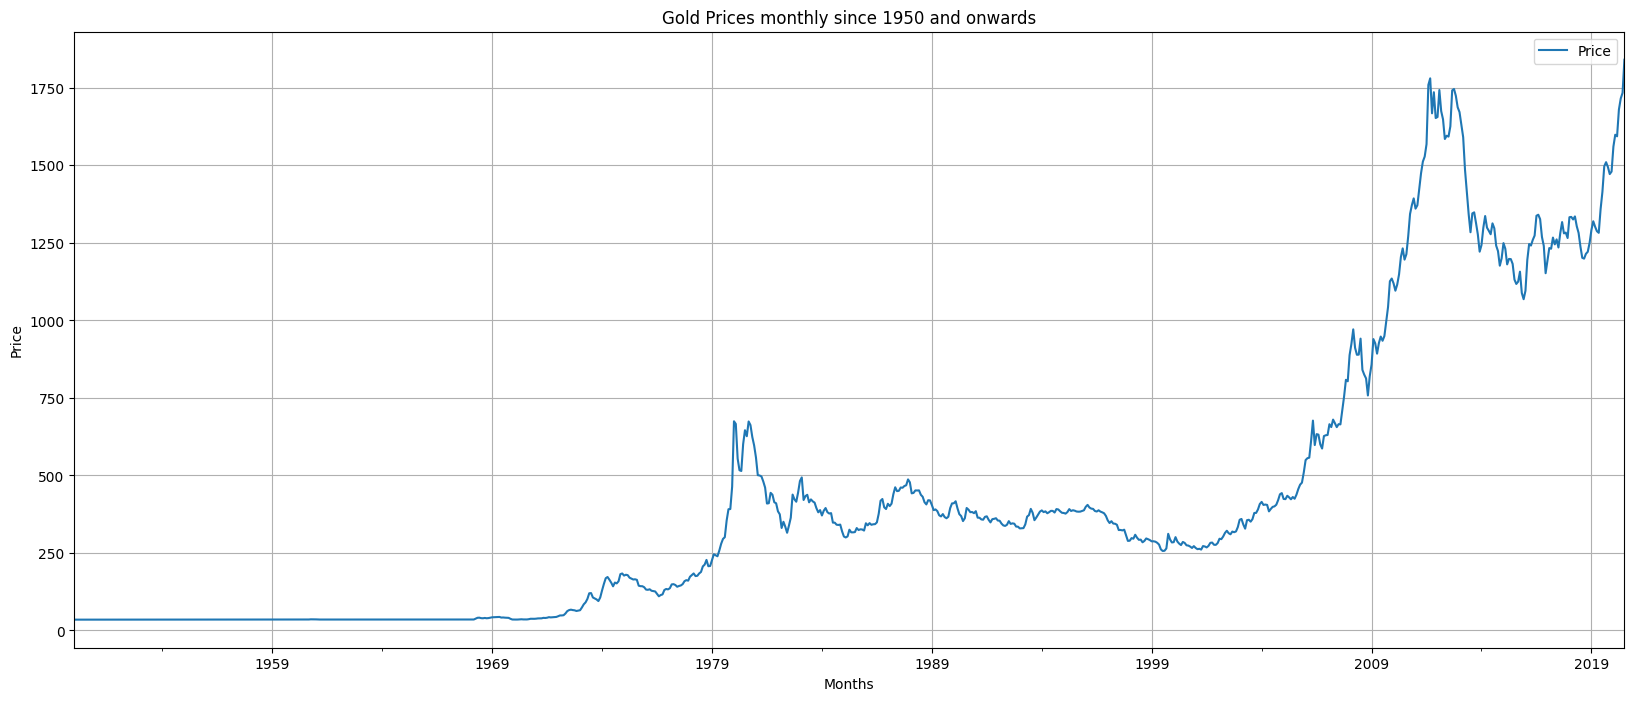

In [7]:
df.plot(figsize=(20, 8))
plt.title("Gold Prices monthly since 1950 and onwards")
plt.xlabel('Months')
plt.ylabel('Price')
plt.grid()

In [8]:
round(df.describe(), 3)

,Price
count,847.000
mean,416.557
std,453.665
min,34.490
25%,35.190
50%,319.622
75%,447.029
max,1840.807


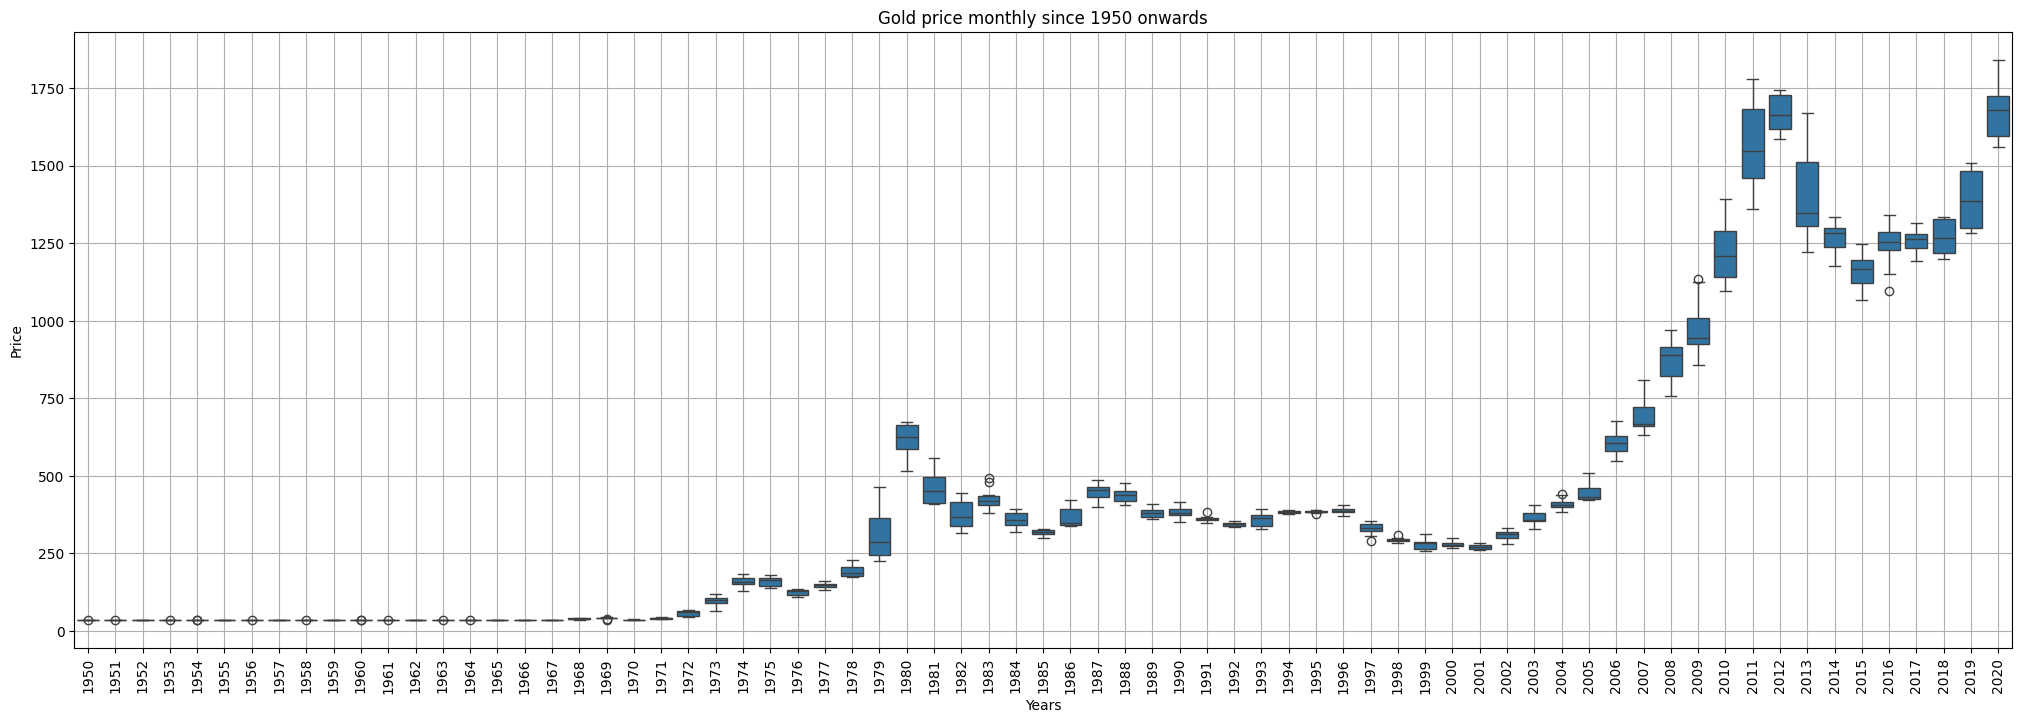

In [9]:
_, ax = plt.subplots(figsize=(25, 8))
sns.boxplot(x=df.index.year, y=df.values[:, 0], ax=ax)
plt.title("Gold price monthly since 1950 onwards")
plt.xlabel('Years')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.grid()

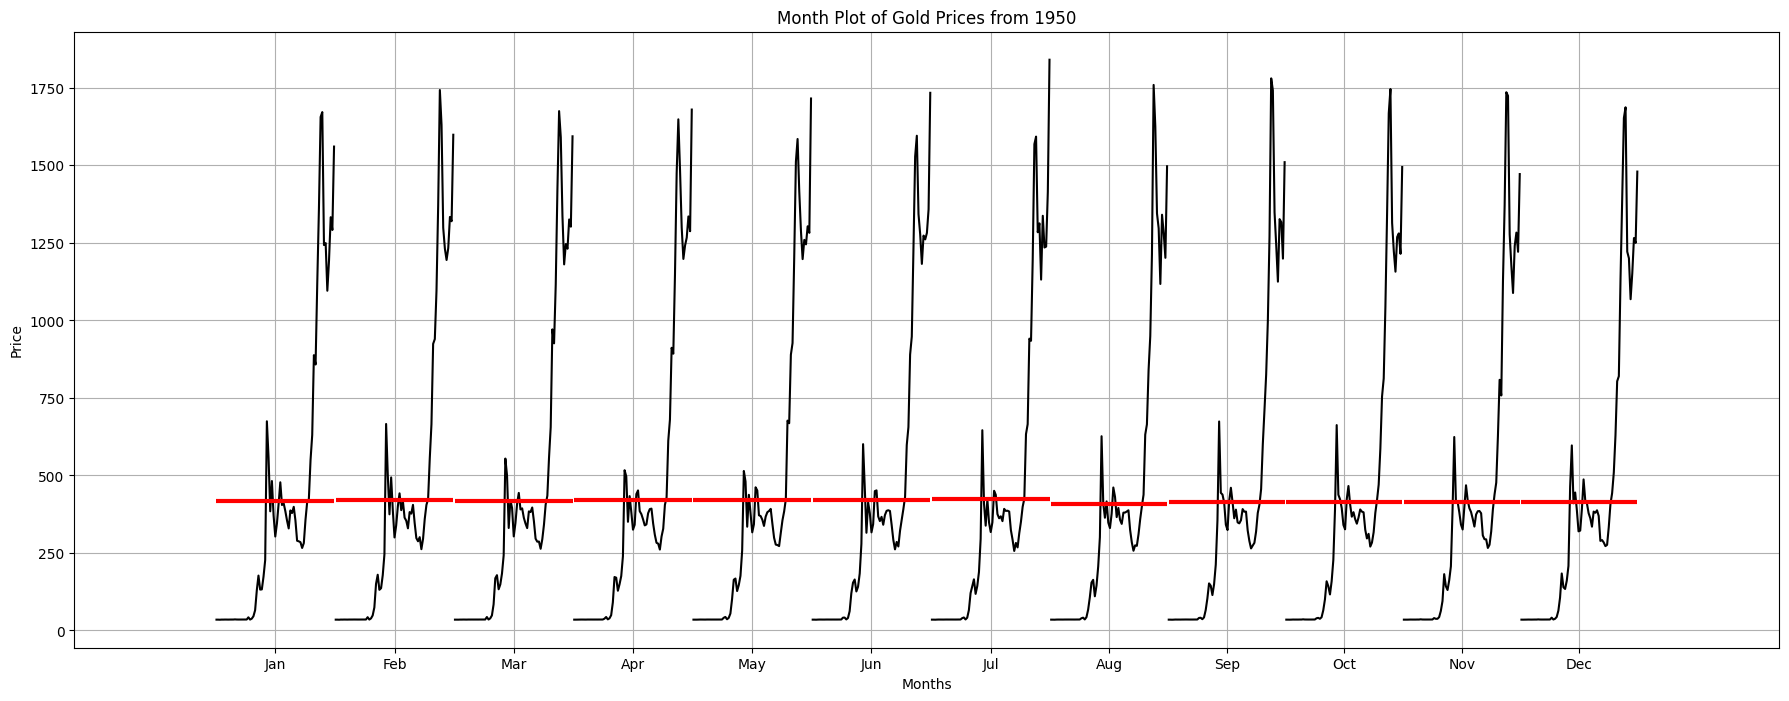

In [10]:
from statsmodels.graphics.tsaplots import month_plot

fig, ax = plt.subplots(figsize=(22, 8))
month_plot(df, ylabel='Gold Price', ax=ax)
plt.title("Month Plot of Gold Prices from 1950") 
plt.xlabel('Months')
plt.ylabel('Price')
plt.grid()

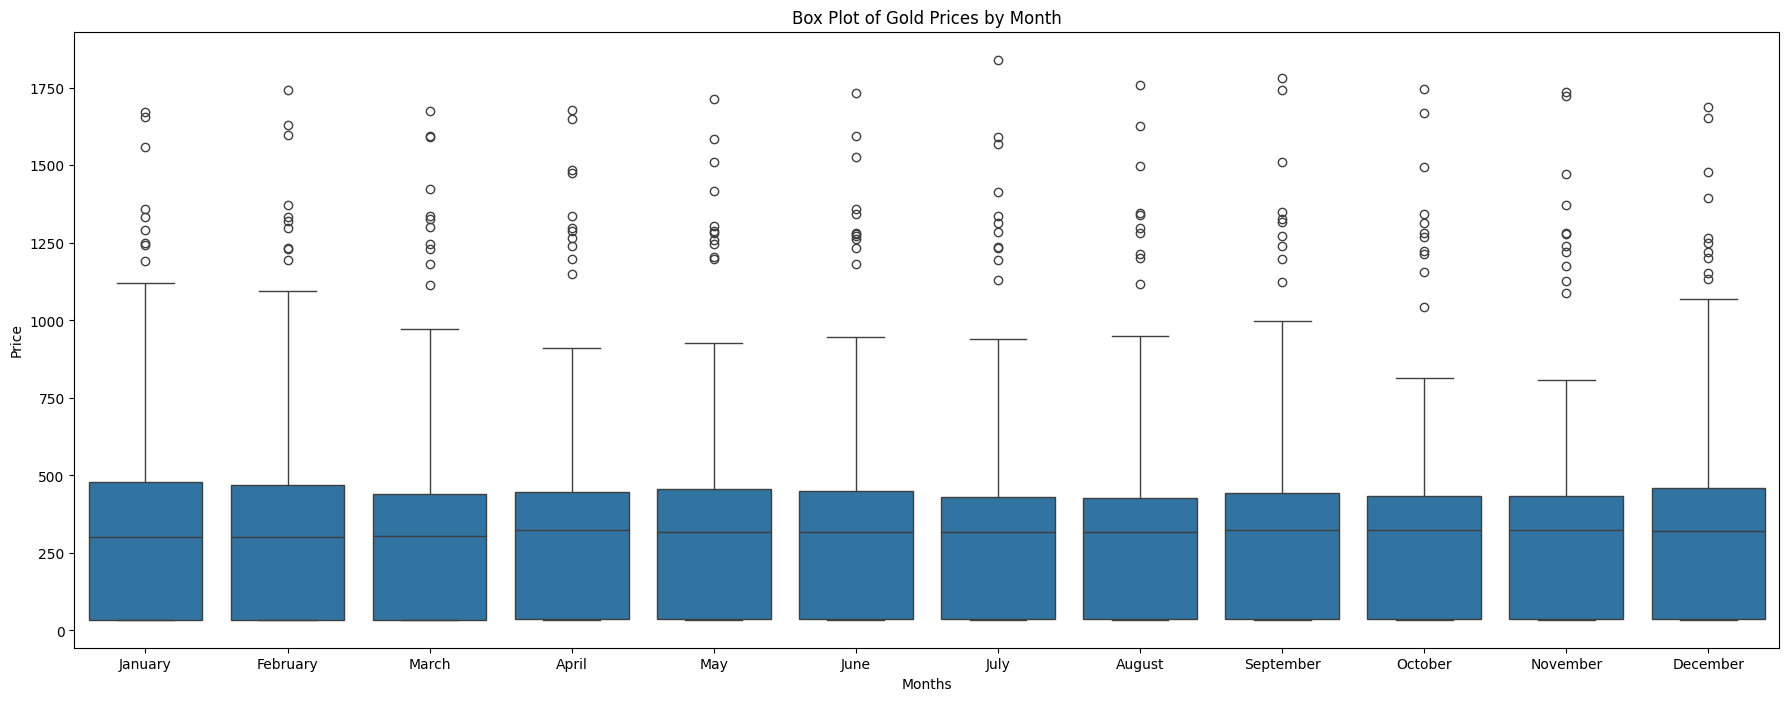

In [11]:
_, ax = plt.subplots(figsize=(22, 8))
sns.boxplot(x=df.index.month_name(), y=df.values[:, 0], ax=ax)
plt.title("Box Plot of Gold Prices by Month")
plt.xlabel('Months')
plt.ylabel('Price')
plt.show()

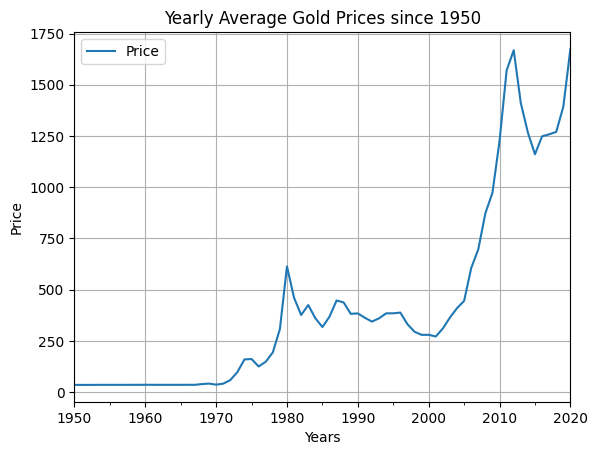

In [12]:
df_yearly_sum = df.resample('A').mean()
df_yearly_sum.plot()
plt.title("Yearly Average Gold Prices since 1950")
plt.xlabel('Years')
plt.ylabel('Price')
plt.grid()

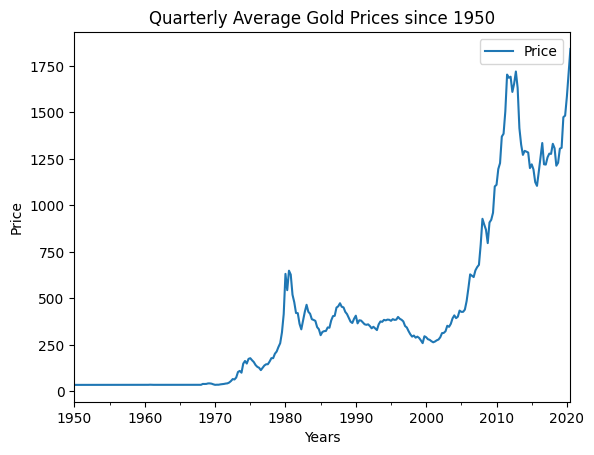

In [13]:
df_quarterly_sum = df.resample('Q').mean()
df_quarterly_sum.plot()
plt.title("Quarterly Average Gold Prices since 1950")
plt.xlabel('Years')
plt.ylabel('Price')
plt.show()

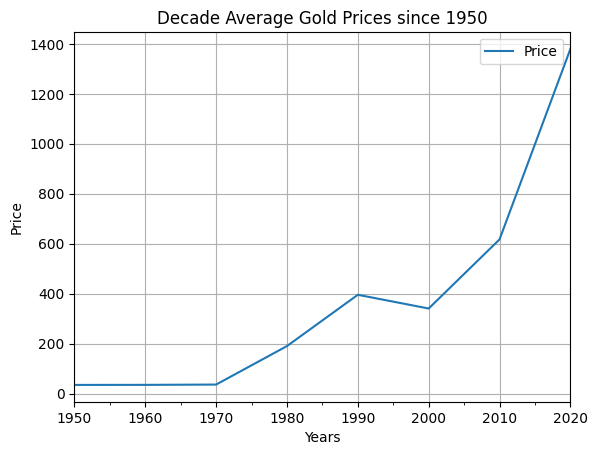

In [14]:
df_decade_sum = df.resample('10Y').mean()
df_decade_sum.plot()
plt.title("Decade Average Gold Prices since 1950")
plt.xlabel('Years')
plt.ylabel('Price')
plt.grid()

In [15]:
df_1 = df.groupby(df.index.year).mean().rename(columns={'Price': 'Mean'})

df_1 = df_1.merge(df.groupby(df.index.year).std().rename(columns={'Price': 'Std'}), left_index=True, right_index=True)

df_1['Cov_pct'] =  ((df_1['Std'] / df_1['Mean']) * 100).round(2)
df_1.head()

,Mean,Std,Cov_pct
month,,,
1950,34.729167,0.002887,0.01
1951,34.717500,0.020057,0.06
1952,34.628333,0.117538,0.34
1953,34.879167,0.056481,0.16
1954,35.020000,0.082792,0.24


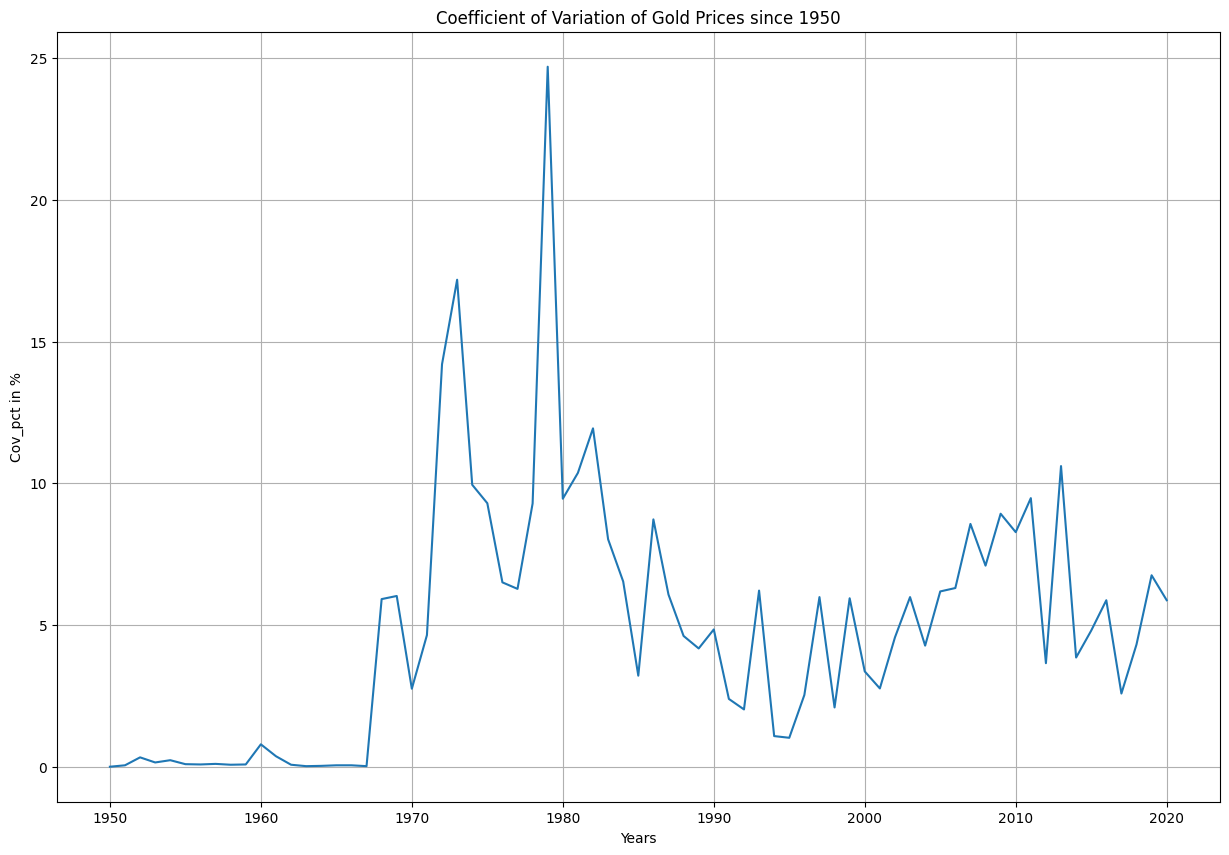

In [16]:
fig, ax = plt.subplots(figsize=(15, 10))
df_1['Cov_pct'].plot()
plt.title("Coefficient of Variation of Gold Prices since 1950")
plt.xlabel('Years')
plt.ylabel('Cov_pct in %')
plt.grid()

In [17]:
train = df[df.index.year <= 2015]
test = df[df.index.year > 2015]

In [18]:
print(train.shape)
print(test.shape)

(792, 1)
(55, 1)


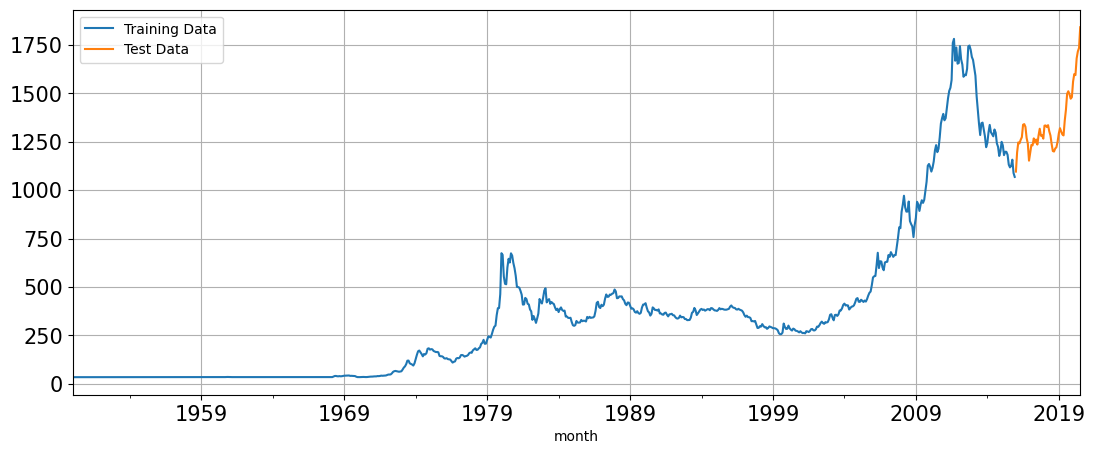

In [19]:
train['Price'].plot(fontsize = 15, figsize=(13, 5))
test['Price'].plot(fontsize = 15, figsize=(13, 5))

plt.grid()
plt.legend(['Training Data', 'Test Data'])
plt.show()

In [20]:
train_time = [i + 1 for i in range(len(train))]
test_time = [i + len(train)+1 for i in range(len(test))]
len(train_time), len(test_time)

(792, 55)

In [21]:
LR_train = train.copy()
LR_test = test.copy()

In [22]:
LR_train['time'] = train_time
LR_test['time'] = test_time

In [23]:
lr = LinearRegression()
lr.fit(LR_train[['time']], LR_train['Price'].values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


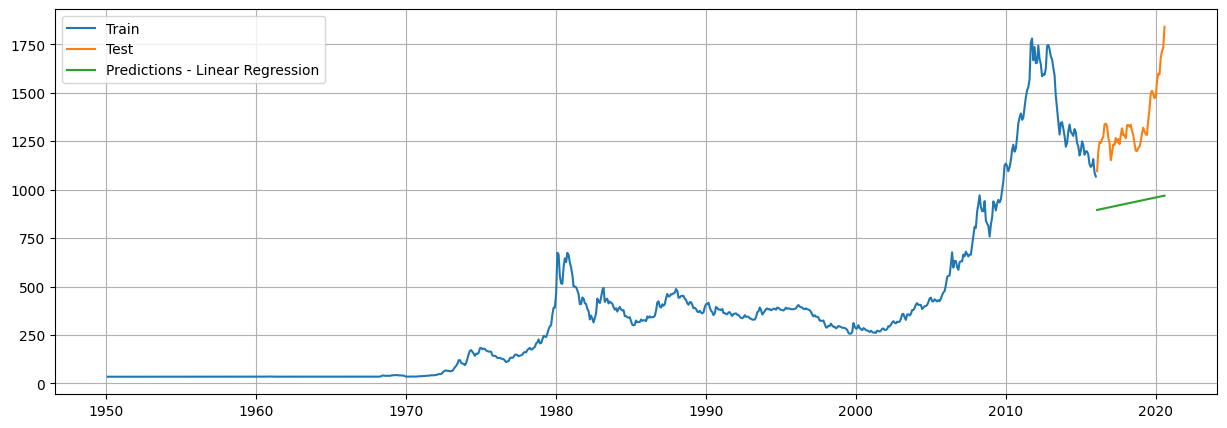

In [24]:
test_predictions_model1 = lr.predict(LR_test[['time']])
LR_test['forecast'] = test_predictions_model1

plt.figure(figsize=(15, 5))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.plot(LR_test['forecast'], label='Predictions - Linear Regression')
plt.legend(loc='best')
plt.grid()

In [25]:
def mape(actual, pred):
    return round((np.mean(abs(actual - pred) / actual)) * 100, 2)

In [26]:
mape_model1_test = mape(test['Price'].values, test_predictions_model1)

print("MAPE is %3.3f" % (mape_model1_test), "%")

MAPE is 29.760 %


In [27]:
results = pd.DataFrame({'Test Mape (%)': [mape_model1_test]}, index=['RegressionOnTime'])
results

,Test Mape (%)
RegressionOnTime,29.76


In [28]:
Naive_train = train.copy()
Naive_test = test.copy()

In [29]:
Naive_test['naive'] = np.asarray(train['Price'])[len(np.asarray(train['Price']))-1]

Naive_test['naive'].head()

month
2016-01-31    1068.317
2016-02-29    1068.317
2016-03-31    1068.317
2016-04-30    1068.317
2016-05-31    1068.317
Name: naive, dtype: float64

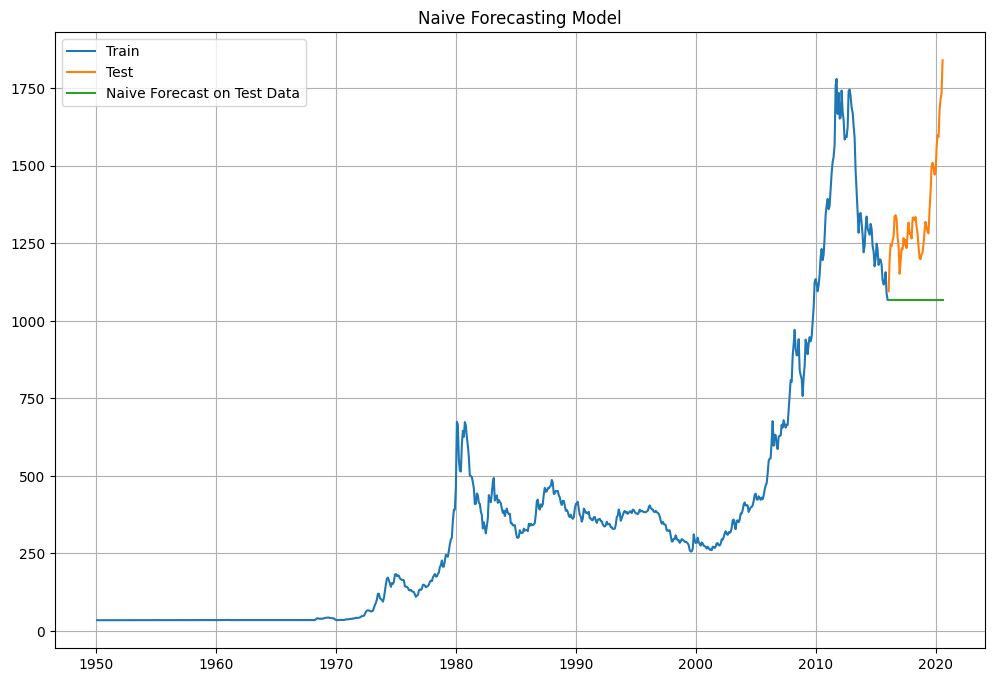

In [30]:
plt.figure(figsize=(12, 8))
plt.plot(Naive_train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.plot(Naive_test['naive'], label='Naive Forecast on Test Data')
plt.legend(loc='best')
plt.title("Naive Forecasting Model")
plt.grid()

In [31]:
mape_model2_test = mape(test['Price'].values, Naive_test['naive'].values)

print("For Naive Forecast on the Test Data, MAPE is %3.3f" % (mape_model2_test), "%")

For Naive Forecast on the Test Data, MAPE is 19.380 %


In [32]:
resultsDf_2 = pd.DataFrame({'Test Mape (%)': [mape_model2_test]}, index=['NaiveModel'])
results = pd.concat([results, resultsDf_2])
results

,Test Mape (%)
RegressionOnTime,29.76
NaiveModel,19.38


In [33]:
final_model = ExponentialSmoothing(df, trend='additive', seasonal='additive').fit(smoothing_level=0.4, smoothing_trend=0.3, smoothing_seasonal=0.6)

In [34]:
Mape_final_model = mape(df['Price'].values, final_model.fittedvalues)

print("For the Final Model on the whole data, MAPE is %3.3f" % (Mape_final_model), "%")

For the Final Model on the whole data, MAPE is 17.230 %


In [35]:
predictions = final_model.forecast(steps=len(test))

In [36]:
pred_df = pd.DataFrame({'lower_CI': predictions - 1.96 * np.std(final_model.resid, ddof=1), 'prediction': predictions, 'upper_CI': predictions + 1.96 * np.std(final_model.resid, ddof=1)})

pred_df.head()

,lower_CI,prediction,upper_CI
2020-08-31,1684.722153,1792.873129,1901.024104
2020-09-30,1615.309735,1723.460710,1831.611685
2020-10-31,1538.573100,1646.724075,1754.875050
2020-11-30,1476.765031,1584.916007,1693.066982
2020-12-31,1459.334548,1567.485523,1675.636498


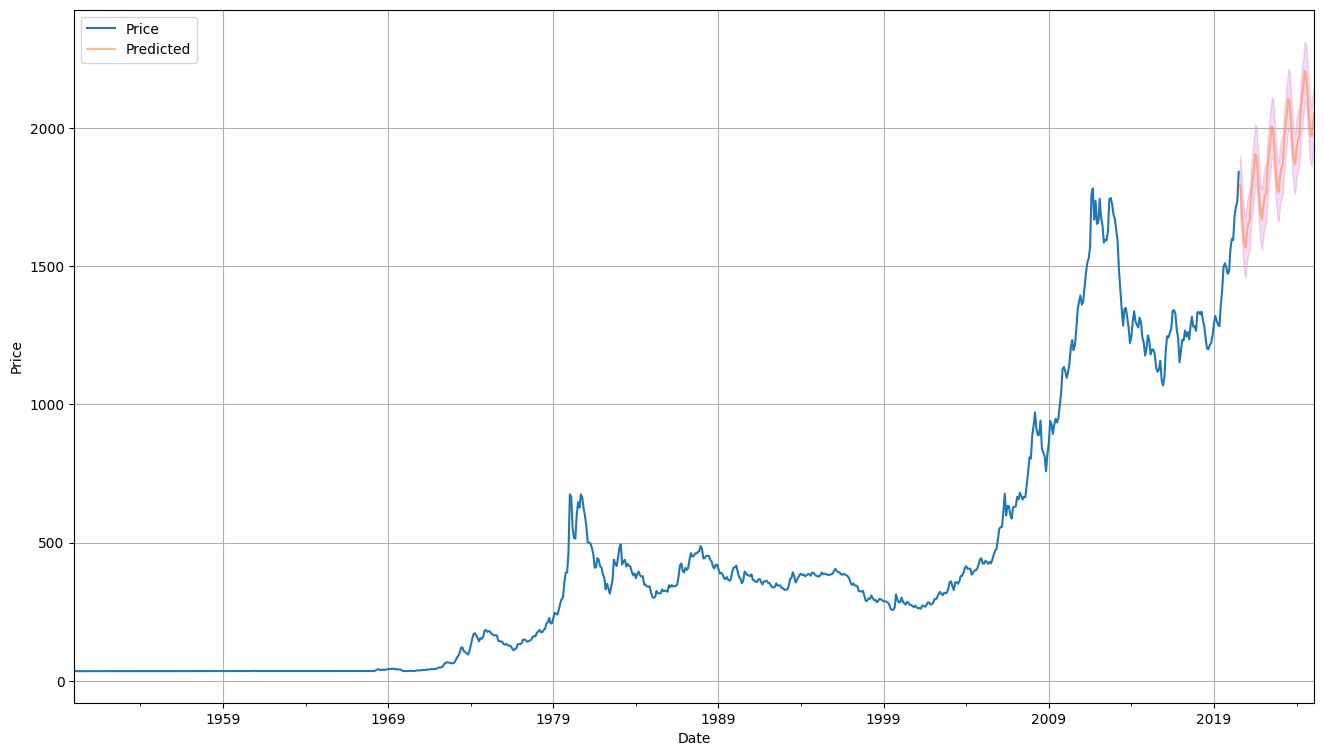

In [37]:
axis = df.plot(figsize=(16, 9), label='Actual')
pred_df['prediction'].plot(ax=axis, label='Predicted', alpha=0.5)
axis.fill_between(pred_df.index, pred_df['lower_CI'], pred_df['upper_CI'], color='m', alpha=.15)

axis.set_xlabel("Date")
axis.set_ylabel("Price")
plt.legend(loc='best')
plt.grid()
plt.show()